## Imports

In [10]:
import pandas as pd
import numpy as np
import joblib

In [11]:
df = pd.read_csv('../dataset/code_dataset.csv')
df.head()

,code,loops,maxDepth,recursion,label
0,public int sumArray(int[] arr) {\n int sum = ...,1,1,False,Efficient
1,"public int binarySearch(int[] arr, int target)...",1,1,False,Efficient
2,public void bubbleSort(int[] arr) {\n for (in...,2,2,False,Inefficient
3,public int factorial(int n) {\n if (n <= 1) r...,0,0,True,Efficient
4,public int fibonacci(int n) {\n if (n <= 1) r...,0,0,True,Inefficient


### Load pkl file

In [12]:
X_train, X_test, y_train, y_test = joblib.load('../models/data.pkl')

### Import models

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

Logistic Regression
accuracy: 0.5000

classification Report:
              precision    recall  f1-score   support

   Efficient       0.67      0.89      0.76         9
 Inefficient       0.00      0.00      0.00         7
    Moderate       0.25      0.50      0.33         4

    accuracy                           0.50        20
   macro avg       0.31      0.46      0.37        20
weighted avg       0.35      0.50      0.41        20



/home/sugaredcookie/Projects/DSA_model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sugaredcookie/Projects/DSA_model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sugaredcookie/Projects/DSA_model/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

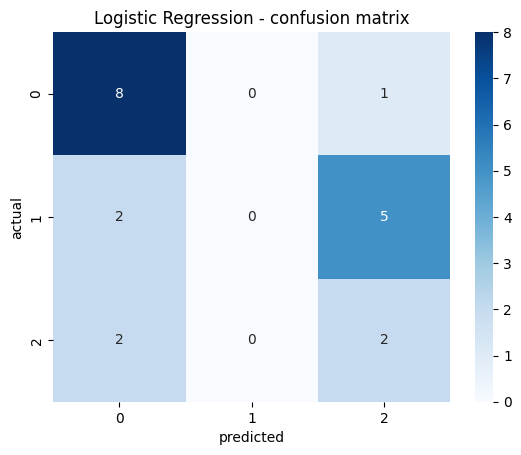

Decision Tree
accuracy: 0.6500

classification Report:
              precision    recall  f1-score   support

   Efficient       0.69      1.00      0.82         9
 Inefficient       1.00      0.29      0.44         7
    Moderate       0.40      0.50      0.44         4

    accuracy                           0.65        20
   macro avg       0.70      0.60      0.57        20
weighted avg       0.74      0.65      0.61        20



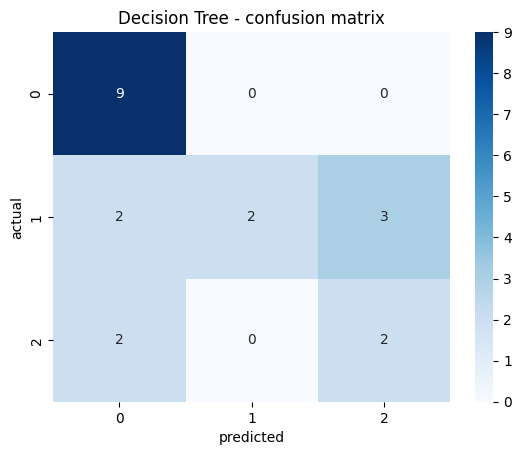

Random Forest
accuracy: 0.6000

classification Report:
              precision    recall  f1-score   support

   Efficient       0.67      0.89      0.76         9
 Inefficient       1.00      0.29      0.44         7
    Moderate       0.33      0.50      0.40         4

    accuracy                           0.60        20
   macro avg       0.67      0.56      0.54        20
weighted avg       0.72      0.60      0.58        20



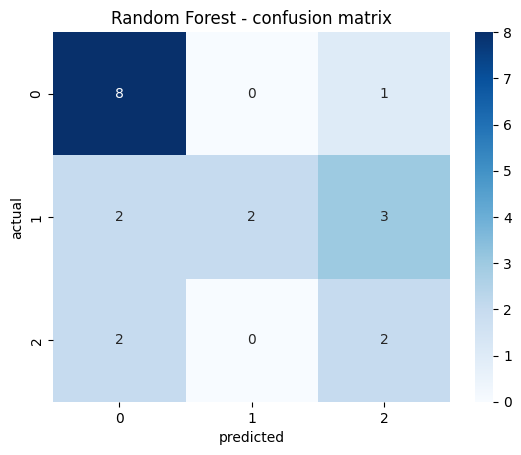

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():
    print(name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"accuracy: {acc:.4f}")

    # Classification report
    print("\nclassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.show()

## Hyperparameter tuning

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5],
}

rf = RandomForestClassifier(random_state=42)

In [19]:
grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [20]:
print("best parameters: ", grid.best_params_)
print("best corss validation score: ", grid.best_score_)

best parameters:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
best corss validation score:  0.8125


## Lets test

In [21]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("tuned random forest")
print(f'test accuracy: {accuracy_score(y_test, y_pred)}')
print(f'classification report: \n{classification_report(y_test, y_pred)}')

cm = confusion_matrix(y_test, y_pred)
print(f'confusion matrix: \n{cm}')

tuned random forest
test accuracy: 0.65
classification report: 
              precision    recall  f1-score   support

   Efficient       0.69      1.00      0.82         9
 Inefficient       1.00      0.29      0.44         7
    Moderate       0.40      0.50      0.44         4

    accuracy                           0.65        20
   macro avg       0.70      0.60      0.57        20
weighted avg       0.74      0.65      0.61        20

confusion matrix: 
[[9 0 0]
 [2 2 3]
 [2 0 2]]


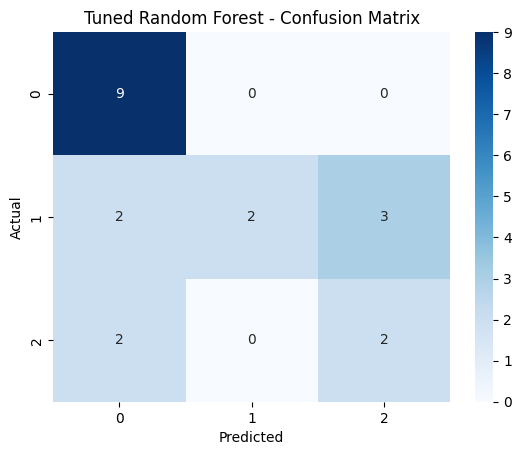

In [27]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Export

In [28]:
import joblib
joblib.dump(best_model, "../models/rf_model.pkl")

['../models/rf_model.pkl']

### the overall performance of the model is moderate due to several factors affecting it, the kind of dataset needing for this project isint publically available on the internet so i had to create one of my own which had very less data, since the dataset is limited, evaluation is unstable and the slightest missclassification leaves a big impact on the accuracy 


### the purpose of the model is not to acieve a very high predictive accuracy score but rather demonstrate a complete pipeline and i give assurance that with the right amount of the data, the performance of the model with this existing pipeline would be statisfactory

# End of model training